In [2]:
import mysql.connector
import pandas as pd

groundtruth_sheet_id = '18HCMbUmXcK9N2d4GziwUrHUgEHnc81ZH_4v-r-uJKcI' #Sheet with list of groundtruth sheets
big_dataset_range = "BigDataset!A1:C"

mydb = mysql.connector.connect(
  host="localhost",
  user="root",
  password="MyN3wP4ssw0rd",
  database="democratizeesg"
)

mycursor = mydb.cursor()

sql_query = ("SELECT company_name, year "
             "FROM democratizeesg.big_dataset_consolidated_unit_converted3 "
             "WHERE indicator_id IN ('ghg_scope1', 'ghg_scope2_market', 'ghg_scope3', 'revenue')     "
             "AND not_disclosed = 0 "
             "GROUP BY    company_name, year "
             "HAVING    COUNT(DISTINCT indicator_id) = 4;")
mycursor.execute(sql_query)
results = mycursor.fetchall()

columns = [col[0] for col in mycursor.description]
testable_companies = pd.DataFrame(results, columns=columns)

intensity_base_data = pd.DataFrame()

In [2]:
for index, row in testable_companies.iterrows():

  sql_query = ("SELECT industry, company_name, year, indicator_id, value, unit "
               "FROM democratizeesg.big_dataset_consolidated_unit_converted3 "
               "WHERE (indicator_id = 'ghg_scope1' OR indicator_id = 'ghg_scope2_market' OR indicator_id = 'ghg_scope3' OR indicator_id = 'revenue') "
               "AND company_name = %s AND year = %s")
  val = [row['company_name'], row['year']]
  mycursor.execute(sql_query, val)
  results = mycursor.fetchall()

  columns = [col[0] for col in mycursor.description]
  retrieved_company_infos = pd.DataFrame(results, columns=columns)
  intensity_base_data = pd.concat([intensity_base_data, retrieved_company_infos], axis=0)

In [48]:
testable_companies.sort_values('intensity_percent_change', ascending=False, inplace=True)

testable_companies.head(50)

,company_name,year,intensity,scope1,scope2,scope3,revenue,intensity_percent_change
8,AB Volvo,2024,5.472883,0.21,0.06,262.10,47.94,48195.79
414,TheHomeDepot,2023,1.479741,0.63,0.73,192.93,131.30,3708.22
242,JBS,2021,1.156072,4.68,1.40,65.03,61.51,706.87
326,POSCO Holdings Inc.,2023,1.602769,76.86,1.97,12.64,57.07,372.62
348,"Repsol, S.A.",2024,3.674720,13.70,0.30,195.90,57.12,199.18
159,Eni,2023,4.337903,38.69,0.73,371.90,94.82,184.03
395,Stellantis,2022,2.276240,1.36,1.74,405.69,179.59,146.91
406,Tata Steel Ltd.,2022,3.939138,75.70,5.60,11.90,23.66,115.04
187,Fortum,2022,3.432955,17.00,0.03,13.18,8.80,103.01
334,PTT Public Co. Ltd.,2021,7.020262,29.88,1.42,381.00,58.73,101.49


In [3]:
for index, row in testable_companies.iterrows():
  company_name = row['company_name']
  year = row['year']

  scope1 = float(intensity_base_data.query(f"company_name == '{company_name}' and year == {year} and indicator_id == 'ghg_scope1'").iloc[0]['value'])
  scope2 = float(intensity_base_data.query(f"company_name == '{company_name}' and year == {year} and indicator_id == 'ghg_scope2_market'").iloc[0]['value'])
  scope3 = float(intensity_base_data.query(f"company_name == '{company_name}' and year == {year} and indicator_id == 'ghg_scope3'").iloc[0]['value'])
  revenue = float(intensity_base_data.query(f"company_name == '{company_name}' and year == {year} and indicator_id == 'revenue'").iloc[0]['value'])
  intensity = round((scope1 + scope2 + scope3) / revenue,2)

  testable_companies.loc[index, 'scope1'] = scope1
  testable_companies.loc[index, 'scope2'] = scope2
  testable_companies.loc[index, 'scope3'] = scope3
  testable_companies.loc[index, 'revenue'] = revenue
  testable_companies.loc[index, 'intensity'] = intensity

In [4]:
for index, row in testable_companies.iterrows():
    company_name = row['company_name']
    year = int(row['year'])
    intensity = float(row['intensity'])
    intensity_percent_change = 0

    previous_year = testable_companies.query(f"company_name == '{company_name}' and year == {year-1}")
    if not previous_year.empty:
        previous_intensity = float(previous_year.iloc[0]['intensity'])
        change = intensity - previous_intensity
        intensity_percent_change = (change / previous_intensity) * 100

    testable_companies.loc[index, 'intensity_percent_change'] = round(intensity_percent_change, 2)


C:\Users\yotim\AppData\Local\Temp\ipykernel_6508\1551617402.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered.sort_values('intensity_percent_change', ascending=False, inplace=True)


<Axes: ylabel='intensity_percent_change'>

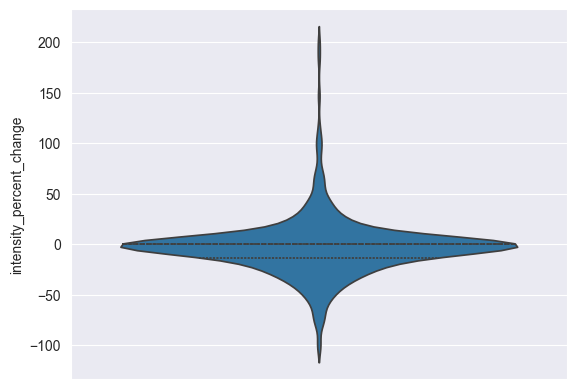

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered = testable_companies.query("intensity_percent_change < 200.0")
filtered.sort_values('intensity_percent_change', ascending=False, inplace=True)


sns.violinplot(data=filtered,
               y="intensity_percent_change",
               inner="quart",
               )

,company_name,year,intensity,scope1,scope2,scope3,revenue,intensity_percent_change
8,AB Volvo,2024,5.472883,0.21,0.06,262.10,47.94,48195.79
414,TheHomeDepot,2023,1.479741,0.63,0.73,192.93,131.30,3708.22
242,JBS,2021,1.156072,4.68,1.40,65.03,61.51,706.87
326,POSCO Holdings Inc.,2023,1.602769,76.86,1.97,12.64,57.07,372.62
348,"Repsol, S.A.",2024,3.674720,13.70,0.30,195.90,57.12,199.18
159,Eni,2023,4.337903,38.69,0.73,371.90,94.82,184.03
395,Stellantis,2022,2.276240,1.36,1.74,405.69,179.59,146.91
406,Tata Steel Ltd.,2022,3.939138,75.70,5.60,11.90,23.66,115.04
187,Fortum,2022,3.432955,17.00,0.03,13.18,8.80,103.01
334,PTT Public Co. Ltd.,2021,7.020262,29.88,1.42,381.00,58.73,101.49


In [23]:
testable_companies_nonzero = testable_companies.query("intensity_percent_change != 0.0")
testable_companies_nonzero_nonoutliers = testable_companies_nonzero.query("intensity_percent_change < 200.0")

testable_companies_nonzero_nonoutliers.describe()

,year,scope1,scope2,scope3,revenue,intensity,intensity_percent_change
count,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000,318.000000
mean,2022.518868,226.051101,25.649560,169.304591,60.689874,7.949245,-3.758365
std,1.079471,1774.861599,238.417949,255.676701,70.330637,27.257918,34.891074
min,2021.000000,0.000000,0.000000,0.010000,0.100000,0.010000,-99.850000
25%,2022.000000,1.670000,0.300000,17.010000,16.807500,1.442500,-21.727500
50%,2023.000000,11.815000,1.025000,65.415000,41.055000,2.785000,-7.285000
75%,2023.000000,36.330000,3.107500,237.250000,73.965000,5.365000,8.885000
max,2024.000000,17721.000000,2629.000000,1395.000000,525.710000,260.320000,198.370000


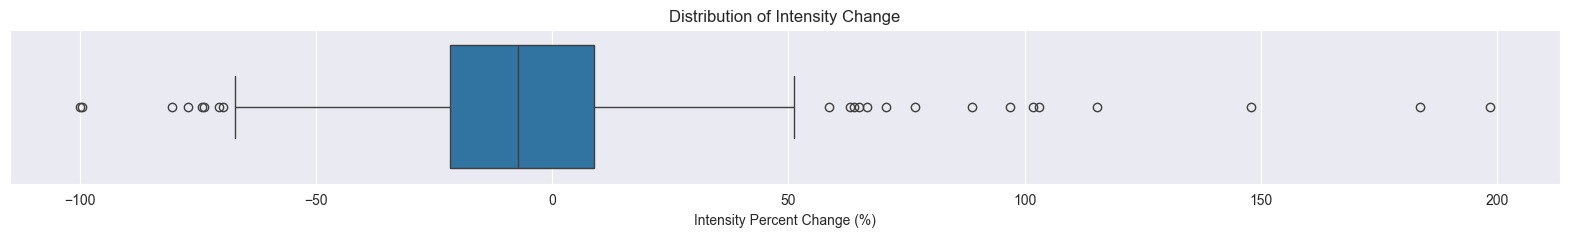

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
testable_companies_nonzero_nonoutliers = testable_companies_nonzero.query("intensity_percent_change < 200.0")

plt.figure(figsize=(20, 2))
sns.boxplot(data=testable_companies_nonzero_nonoutliers, x="intensity_percent_change")
plt.xlabel("Intensity Percent Change (%)")  # This adds the x-axis label
plt.title("Distribution of Intensity Change") # This adds the title
plt.show()

In [82]:
testable_companies_nonzero.describe()

,year,intensity,scope1,scope2,scope3,revenue,intensity_percent_change
count,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000
mean,2022.524691,7.836993,222.135586,25.196543,167.897994,60.589383,159.914907
std,1.077209,27.016824,1758.535422,236.216297,253.857062,69.875745,2685.431838
min,2021.000000,0.008436,0.000000,0.000000,0.010000,0.100000,-99.830000
25%,2022.000000,1.435165,1.650000,0.297500,16.800000,16.962500,-21.462500
50%,2023.000000,2.737994,11.490000,1.025000,65.130000,41.690000,-6.835000
75%,2023.000000,5.353811,36.230000,3.092500,235.750000,71.755000,9.175000
max,2024.000000,260.319303,17721.000000,2629.000000,1395.000000,525.710000,48195.790000


In [93]:
outliers = testable_companies.query("intensity_percent_change > 70.0 or intensity_percent_change < -70.0")
#outliers.shape
outliers.head(21)

,company_name,year,intensity,scope1,scope2,scope3,revenue,intensity_percent_change
8,AB Volvo,2024,5.47,0.21,0.06,262.10,47.94,54600.00
414,TheHomeDepot,2023,1.48,0.63,0.73,192.93,131.30,3600.00
242,JBS,2021,1.16,4.68,1.40,65.03,61.51,728.57
326,POSCO Holdings Inc.,2023,1.60,76.86,1.97,12.64,57.07,370.59
348,"Repsol, S.A.",2024,3.67,13.70,0.30,195.90,57.12,198.37
159,Eni,2023,4.34,38.69,0.73,371.90,94.82,183.66
395,Stellantis,2022,2.28,1.36,1.74,405.69,179.59,147.83
406,Tata Steel Ltd.,2022,3.94,75.70,5.60,11.90,23.66,115.30
187,Fortum,2022,3.43,17.00,0.03,13.18,8.80,102.96
334,PTT Public Co. Ltd.,2021,7.02,29.88,1.42,381.00,58.73,101.72


In [17]:
testable_companies.query("company_name == 'PTT Public Co. Ltd.'").sort_values(by=['year'])

,company_name,year,scope1,scope2,scope3,revenue,intensity,intensity_percent_change
333,PTT Public Co. Ltd.,2020,28.99,1.23,116.15,42.01,3.48,0.00
334,PTT Public Co. Ltd.,2021,29.88,1.42,381.00,58.73,7.02,101.72
335,PTT Public Co. Ltd.,2022,40.41,0.78,119.87,87.55,1.84,-73.79
336,PTT Public Co. Ltd.,2023,36.95,0.79,122.68,81.76,1.96,6.52
337,PTT Public Co. Ltd.,2024,9.85,0.86,299.60,80.35,3.86,96.94


In [3]:
sql_query = ("SELECT company_name, year, indicator_id, not_disclosed, value, unit "
             "FROM democratizeesg.big_dataset_consolidated_unit_converted3 "
             "WHERE industry = 'automobiles' "
             "AND (indicator_id = 'ghg_scope1' OR indicator_id = 'ghg_scope2_market' OR indicator_id = 'revenue') "
             "AND not_disclosed = 0")
mycursor.execute(sql_query)
results = mycursor.fetchall()

columns = [col[0] for col in mycursor.description]
automobiles_data = pd.DataFrame(results, columns=columns)

In [35]:
automobiles_data

,company_name,year,indicator_id,not_disclosed,value,unit
0,BMW,2020,ghg_scope1,0,0.64,million tonnes of CO2
1,BMW,2020,ghg_scope2_market,0,0.08,million tonnes of CO2
2,BMW,2020,revenue,0,98.99,billion euros
3,BMW,2021,ghg_scope1,0,0.7,million tonnes of CO2
4,BMW,2021,ghg_scope2_market,0,0.13,million tonnes of CO2
...,...,...,...,...,...,...
137,Volkswagen,2023,ghg_scope2_market,0,1.96,million tonnes of CO2
138,Volkswagen,2023,revenue,0,322.28,billion euros
139,Volkswagen,2024,ghg_scope1,0,2.72,million tonnes of CO2
140,Volkswagen,2024,ghg_scope2_market,0,0.45,million tonnes of CO2


In [4]:
automobiles_data_pivot = automobiles_data.pivot(
    index=['company_name', 'year'],
    columns='indicator_id',
    values='value'
)

print(f"Shape pre-drop: {automobiles_data_pivot.shape}")
automobiles_data_pivot.dropna(inplace=True)
print(f"Shape post-drop: {automobiles_data_pivot.shape}")

automobiles_data_pivot['ghg_scope1'] = pd.to_numeric(automobiles_data_pivot['ghg_scope1'])
automobiles_data_pivot['ghg_scope2_market'] = pd.to_numeric(automobiles_data_pivot['ghg_scope2_market'])
automobiles_data_pivot['revenue'] = pd.to_numeric(automobiles_data_pivot['revenue'])

automobiles_data_pivot['intensity'] = (automobiles_data_pivot['ghg_scope1'] + automobiles_data_pivot['ghg_scope2_market']) / automobiles_data_pivot['revenue']
automobiles_data_pivot['intensity'] = automobiles_data_pivot['intensity'] * 1000 #thousand tonnes of direct/indirect CO2e per billion euro revenue
#automobiles_data_pivot.query("company_name == 'BMW'")

automobiles_data_pivot.reset_index(inplace=True)
automobiles_data_pivot["year"] = automobiles_data_pivot["year"].astype(int)


Shape pre-drop: (54, 3)
Shape post-drop: (43, 3)


In [5]:
automobiles_data_pivot.reset_index(inplace=True)

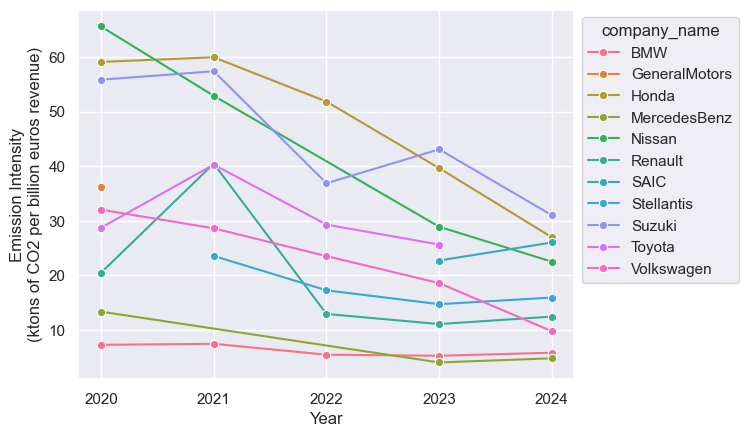

In [33]:
import seaborn as sns
import numpy as np
sns.set_theme(style="darkgrid")

# Load an example dataset with long-form data

# Plot the responses for different events and regions
ax = sns.lineplot(x="year", y="intensity",
             hue="company_name",
             data=automobiles_data_pivot,
                  marker="o")
sns.move_legend(
    ax,
    "upper left",        # Pin the "upper left" corner of the legend...
    bbox_to_anchor=(1, 1)  # ...to the "upper right" (1, 1) of the plot
)
ax.set(xlabel='Year', ylabel='Emission Intensity\n(ktons of CO2 per billion euros revenue)')


years = np.arange(
    int(automobiles_data_pivot["year"].min()),
    int(automobiles_data_pivot["year"].max()) + 1
)
ax.set_xticks(years)

In [18]:
sql_query = ("SELECT company_name, year, indicator_id, not_disclosed, value, unit "
             "FROM democratizeesg.big_dataset_consolidated_unit_converted3 "
             "WHERE industry = 'automobiles' "
             "AND indicator_id = 'fleet_emissions'  "
             "AND not_disclosed = 0")
mycursor.execute(sql_query)
results = mycursor.fetchall()

columns = [col[0] for col in mycursor.description]
automobiles_data_emissions = pd.DataFrame(results, columns=columns)
automobiles_data_emissions['value'] = pd.to_numeric(automobiles_data_emissions['value'])


In [19]:
automobiles_data_emissions.head(10)

,company_name,year,indicator_id,not_disclosed,value,unit
0,BMW,2020,fleet_emissions,0,99.0,gCO₂/km
1,BMW,2021,fleet_emissions,0,115.9,gCO₂/km
2,BMW,2022,fleet_emissions,0,193.7,gCO₂/km
3,BMW,2023,fleet_emissions,0,102.1,gCO₂/km
4,BMW,2024,fleet_emissions,0,99.5,gCO₂/km
5,GeneralMotors,2020,fleet_emissions,0,160.3,gCO₂/km
6,GeneralMotors,2022,fleet_emissions,0,233.0,gCO₂/km
7,GeneralMotors,2023,fleet_emissions,0,294.0,gCO₂/km
8,Honda,2020,fleet_emissions,0,67.8,g/km
9,Honda,2021,fleet_emissions,0,71.2,g/km


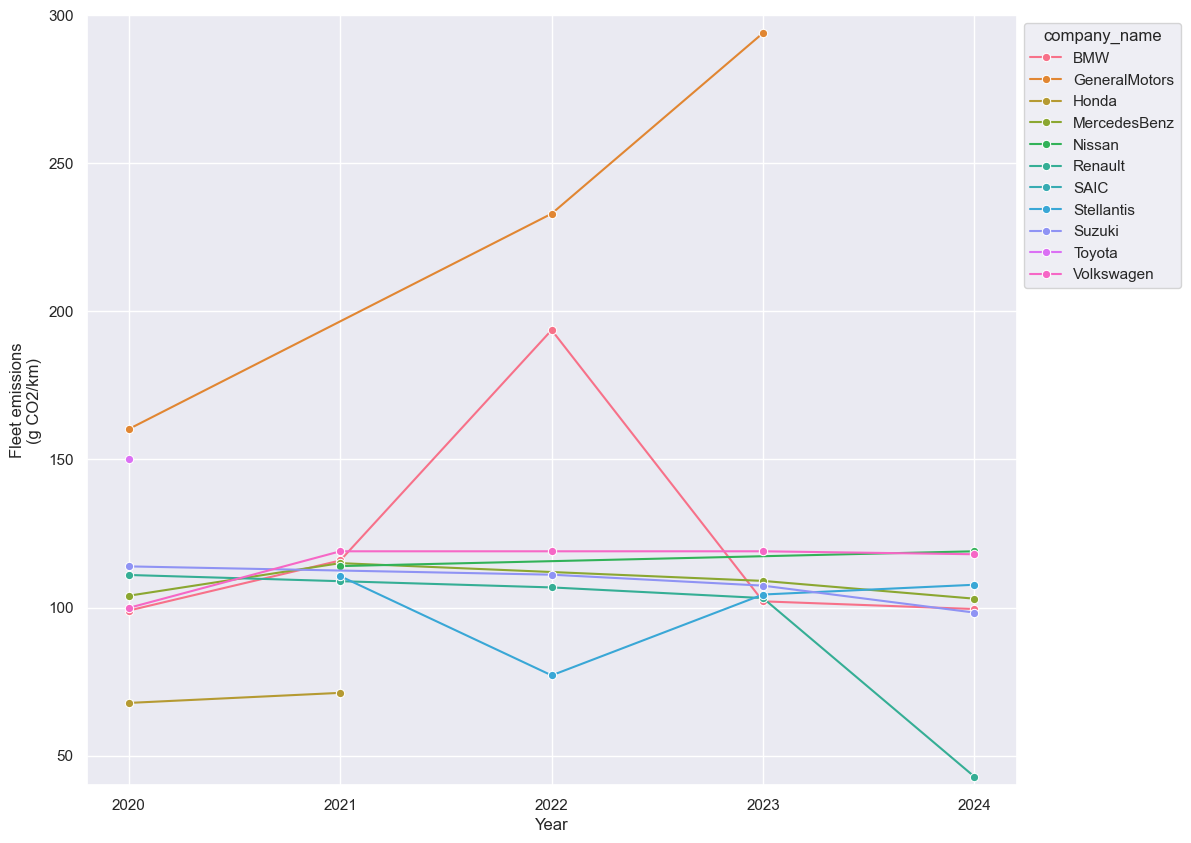

In [34]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 10))
sns.lineplot(x="year", y="value",
             hue="company_name",
             data=automobiles_data_emissions,
                  marker="o")
sns.move_legend(
    ax,
    "upper left",        # Pin the "upper left" corner of the legend...
    bbox_to_anchor=(1, 1)  # ...to the "upper right" (1, 1) of the plot
)
ax.set(xlabel='Year',
       ylabel='Fleet emissions\n(g CO2/km)',
      ylim=(40, 300) )


years = np.arange(
    int(automobiles_data_pivot["year"].min()),
    int(automobiles_data_pivot["year"].max()) + 1
)
ax.set_xticks(years)